<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/SeriesPanel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-3-10bbd39aff60>:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_ts = pd.DataFrame({'Time': pd.date_range(start='2010-01', periods=n, freq='M'), 'Value': series})


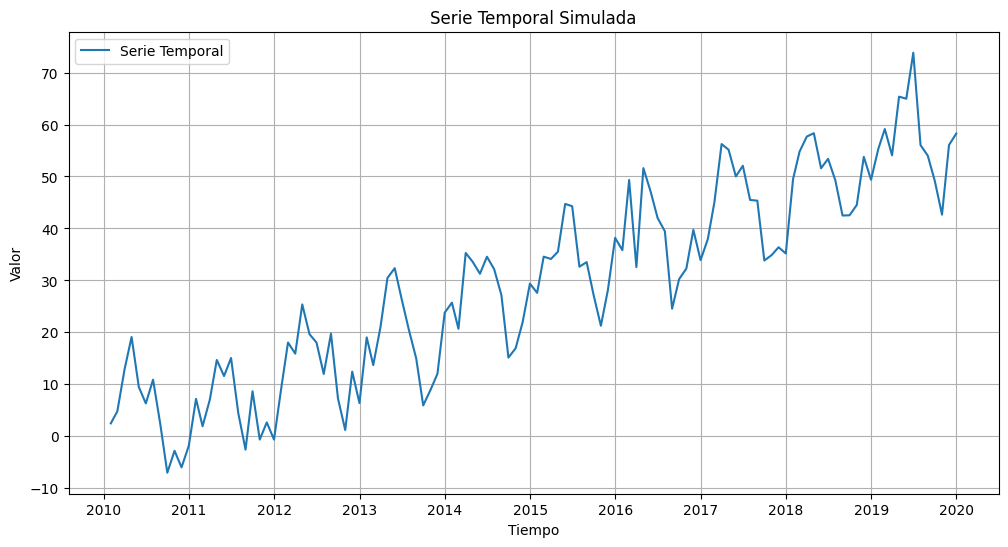

Prueba ADF:
Estadístico: 0.75, p-valor: 0.9909
La serie no es estacionaria

Prueba KPSS:
Estadístico: 1.71, p-valor: 0.0100
La serie no es estacionaria

Resultados del Modelo de Efectos Fijos:
                          PanelOLS Estimation Summary                           
Dep. Variable:            Crecimiento   R-squared:                        0.9994
Estimator:                   PanelOLS   R-squared (Between):              0.9992
No. Observations:                  50   R-squared (Within):               0.9994
Date:                Mon, Jan 06 2025   R-squared (Overall):              0.9992
Time:                        20:12:27   Log-likelihood                   -58.609
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   3.284e+04
Entities:                          10   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(2,3

<ipython-input-3-10bbd39aff60>:45: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(data_ts['Value'], regression='c')


In [ ]:
# Importar las bibliotecas necesarias
!pip install linearmodels
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# ---- SERIES TEMPORALES ----

# Simulación de una serie temporal con tendencia y estacionalidad
np.random.seed(42)
n = 120  # Número de meses
t = np.arange(n)
trend = 0.5 * t
seasonality = 10 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(scale=5, size=n)
series = trend + seasonality + noise

# Crear un DataFrame con la serie temporal
data_ts = pd.DataFrame({'Time': pd.date_range(start='2010-01', periods=n, freq='M'), 'Value': series})
data_ts.set_index('Time', inplace=True)

# Visualización de la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(data_ts, label='Serie Temporal')
plt.title('Serie Temporal Simulada')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid()
plt.show()

# Prueba de estacionariedad ADF (Dickey-Fuller Aumentada)
adf_test = adfuller(data_ts['Value'])
print("Prueba ADF:")
print(f"Estadístico: {adf_test[0]:.2f}, p-valor: {adf_test[1]:.4f}")
print("La serie es estacionaria" if adf_test[1] < 0.05 else "La serie no es estacionaria")

# Prueba de estacionariedad KPSS
kpss_test = kpss(data_ts['Value'], regression='c')
print("\nPrueba KPSS:")
print(f"Estadístico: {kpss_test[0]:.2f}, p-valor: {kpss_test[1]:.4f}")
print("La serie no es estacionaria" if kpss_test[1] < 0.05 else "La serie es estacionaria")

# ---- DATOS DE PANEL ----

# Simulación de datos de panel
np.random.seed(42)
n_firms = 10
n_years = 5
index = pd.MultiIndex.from_product([range(n_firms), range(n_years)], names=['Empresa', 'Año'])
data_panel = pd.DataFrame(index=index)
data_panel['Inversión'] = np.random.uniform(10, 50, size=len(data_panel))
data_panel['Capital'] = np.random.uniform(100, 500, size=len(data_panel))
data_panel['Crecimiento'] = 2 + 0.5 * data_panel['Inversión'] + 0.3 * data_panel['Capital'] + \
                            np.random.randn(len(data_panel))

# Modelo de efectos fijos con la biblioteca linearmodels
panel_data = data_panel.reset_index()
panel_data['Intercepto'] = 1
panel_data.set_index(['Empresa', 'Año'], inplace=True)
model = PanelOLS.from_formula('Crecimiento ~ Inversión + Capital + EntityEffects', panel_data)
results = model.fit()

# Resultados del modelo
print("\nResultados del Modelo de Efectos Fijos:")
print(results.summary)

# Pruebas de heterogeneidad
# Agregar una constante a las variables explicativas
exog_with_const = add_constant(panel_data[['Inversión', 'Capital']])
bp_test = het_breuschpagan(results.resids, exog_with_const)
print("\nPrueba de Heterogeneidad (Breusch-Pagan):")
print(f"Estadístico: {bp_test[0]:.2f}, p-valor: {bp_test[1]:.4f}")

# Pruebas de correlación serial (Ljung-Box)
ljungbox_test = acorr_ljungbox(results.resids, lags=[1], return_df=True)
print("\nPrueba de Correlación Serial (Ljung-Box):")
print(ljungbox_test)
